# Introduction

**Install dependencies**

Installs the Darts package required for time-series analysis.


In [113]:
%pip install -q darts


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


**Inspect NumPy correlation help**

Imports NumPy and displays the documentation for numpy.coeff


**Load the dataset**

Reads the cleaned CSV file into a pandas DataFrame and previews its first five rows.


In [114]:
import pandas as pd

file_path = "../Data/dropout_clean.csv"

df = pd.read_csv(file_path)
print(df[0:5])

     Student ID  Dropout (1=Yes 0=No)  Degree Code  Study Mode  Entry Year  \
0  0002ccc8623e                     0          0.0           1      2021.0   
1  00075bbc7af3                     0          1.0           1      2022.0   
2  0008337bd791                     0          2.0           1      2020.0   
3  000be0ddb26c                     0          3.0           1      2022.0   
4  000d5aac651d                     0          4.0           1      2019.0   

   Admission Type  Active Enrollment  Displaced Student Second Degree Student  \
0               1                  1                  1                   NaN   
1               2                  1                  0                   1,0   
2               3                  1                  0                   NaN   
3               3                  1                  1                   NaN   
4               3                  1                  1                   NaN   

   Overall Pass Rate (%)  ...  Platform Even

**Check index uniqueness**

Verifies whether every row in the DataFrame has a unique index value.


In [115]:
df.index.is_unique


True

**Remove missing values**

Creates a cleaned DataFrame by dropping rows that contain missing values.


In [116]:
df_cleaned = pd.DataFrame.dropna(df)

print(df_cleaned)

Empty DataFrame
Columns: [Student ID, Dropout (1=Yes 0=No), Degree Code, Study Mode, Entry Year, Admission Type, Active Enrollment, Displaced Student, Second Degree Student, Overall Pass Rate (%), Pass Rate Semester A (%), Pass Rate Semester B (%), Pass Rate Last Year (%), Pass Rate 2 Years Ago (%), Credits Enrolled Total, Credits Passed Total, Credits Passed Normal, Credits Passed Sem A, Credits Passed Sem B, Credits Pending Grade, Lowest Year of Study, Highest Year of Study, Unpaid Fees Flag, Platform Days Logged (Total), Platform Events (Total), Platform Minutes (Total), Platform Visits (Total), Campus WiFi Days (Total), Resource Access Days (Total), Assignment Submissions (Total), Test Submissions (Total), Performance Bucket, Engagement Level, Credits Enrolled Band]
Index: []

[0 rows x 34 columns]


**Remove the student identifier**

Drops the `Student ID` column because an identifier is not useful for correlation analysis.


In [117]:
label = "Student ID"
df_without_studentid = df.drop(columns=label)
print(df_without_studentid)

       Dropout (1=Yes 0=No)  Degree Code  Study Mode  Entry Year  \
0                         0          0.0           1      2021.0   
1                         0          1.0           1      2022.0   
2                         0          2.0           1      2020.0   
3                         0          3.0           1      2022.0   
4                         0          4.0           1      2019.0   
...                     ...          ...         ...         ...   
20422                     0         17.0           1         NaN   
20423                     1         10.0           1      2022.0   
20424                     0         42.0           1      2019.0   
20425                     0          6.0           1      2021.0   
20426                     0          5.0           1      2020.0   

       Admission Type  Active Enrollment  Displaced Student  \
0                   1                  1                  1   
1                   2                  1                 

**Remove non-numeric categories**

Drops categorical code columns that should not be included directly in the numeric correlation matrix.


In [118]:
label1 = ["Degree Code", "Admission Type"]
df = df_without_studentid.drop(columns=label1)
print(df)

       Dropout (1=Yes 0=No)  Study Mode  Entry Year  Active Enrollment  \
0                         0           1      2021.0                  1   
1                         0           1      2022.0                  1   
2                         0           1      2020.0                  1   
3                         0           1      2022.0                  1   
4                         0           1      2019.0                  1   
...                     ...         ...         ...                ...   
20422                     0           1         NaN                  0   
20423                     1           1      2022.0                  0   
20424                     0           1      2019.0                  0   
20425                     0           1      2021.0                  1   
20426                     0           1      2020.0                  1   

       Displaced Student Second Degree Student  Overall Pass Rate (%)  \
0                      1              

**Convert values to numeric data**

Replaces decimal commas with decimal points and converts every remaining column to a numeric type.


In [119]:
df = df.replace(",", ".", regex=True)
df = df.apply(pd.to_numeric)

**Inspect the numeric dataset**

Displays the prepared DataFrame before calculating correlations.


In [120]:
print(df)

       Dropout (1=Yes 0=No)  Study Mode  Entry Year  Active Enrollment  \
0                         0           1      2021.0                  1   
1                         0           1      2022.0                  1   
2                         0           1      2020.0                  1   
3                         0           1      2022.0                  1   
4                         0           1      2019.0                  1   
...                     ...         ...         ...                ...   
20422                     0           1         NaN                  0   
20423                     1           1      2022.0                  0   
20424                     0           1      2019.0                  0   
20425                     0           1      2021.0                  1   
20426                     0           1      2020.0                  1   

       Displaced Student  Second Degree Student  Overall Pass Rate (%)  \
0                      1             

**Calculate the correlation matrix**

Computes pairwise Pearson correlations between numeric variables and prints the result.


In [121]:
corr_matrix = df.corr()
corr_vector = df.corr()["Dropout (1=Yes 0=No)"]

print(corr_vector)


Dropout (1=Yes 0=No)              1.000000
Study Mode                       -0.093341
Entry Year                        0.031911
Active Enrollment                -0.346569
Displaced Student                 0.007024
Second Degree Student                  NaN
Overall Pass Rate (%)            -0.331713
Pass Rate Semester A (%)         -0.205245
Pass Rate Semester B (%)         -0.325803
Pass Rate Last Year (%)          -0.129342
Pass Rate 2 Years Ago (%)        -0.139705
Credits Enrolled Total           -0.123311
Credits Passed Total             -0.230987
Credits Passed Normal            -0.235223
Credits Passed Sem A             -0.159786
Credits Passed Sem B             -0.191758
Credits Pending Grade             0.113014
Lowest Year of Study             -0.091696
Highest Year of Study            -0.101659
Unpaid Fees Flag                       NaN
Platform Days Logged (Total)     -0.073066
Platform Events (Total)          -0.032087
Platform Minutes (Total)         -0.079817
Platform Vi

**Plot a basic correlation matrix**

Uses Matplotlib to display the complete correlation matrix as a color-coded image.


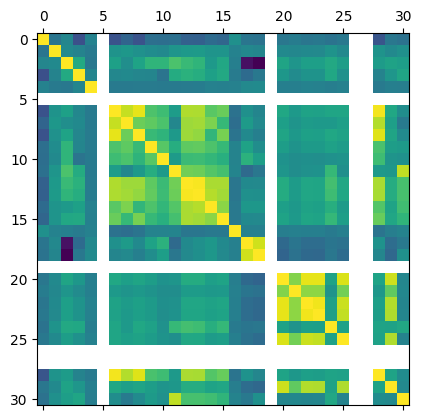

In [122]:
import matplotlib.pyplot as plt

plt.matshow(corr_matrix)
plt.show()

**Plot a detailed correlation heatmap**

Uses Seaborn to show annotated correlation values with a centered diverging color scale.


**Reordering Correlation Matrix by top 10 highest absolute values***

In [144]:
corr_vector = corr_vector.sort_values(key=abs, ascending=False)
reference_col = "Dropout (1=Yes 0=No) "
correlation_df = corr_vector[0:20].to_frame(name=f"Correlation with '{reference_col}'")
print(correlation_df)

                           Correlation with 'Dropout (1=Yes 0=No) '
Dropout (1=Yes 0=No)                                       1.000000
Active Enrollment                                         -0.346569
Overall Pass Rate (%)                                     -0.331713
Pass Rate Semester B (%)                                  -0.325803
Performance Bucket                                        -0.313989
Credits Passed Normal                                     -0.235223
Credits Passed Total                                      -0.230987
Pass Rate Semester A (%)                                  -0.205245
Credits Passed Sem B                                      -0.191758
Credits Passed Sem A                                      -0.159786
Pass Rate 2 Years Ago (%)                                 -0.139705
Pass Rate Last Year (%)                                   -0.129342
Credits Enrolled Total                                    -0.123311
Credits Pending Grade                           

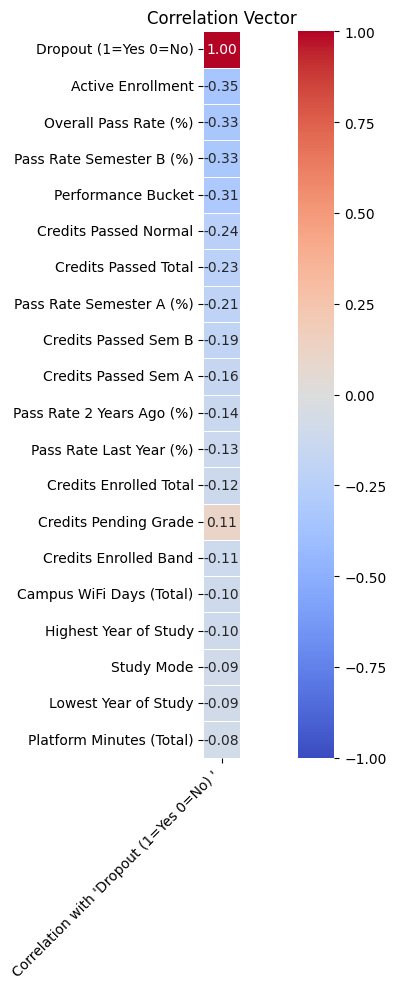

In [145]:
import seaborn as sns

plt.figure(figsize=(12, 10))

sns.heatmap(
    correlation_df,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Correlation Vector")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()